# INF-0616 - Projeto 2: *SVR, Grid Search & Random Search*

Professora: Esther Colombini -- esther@ic.unicamp.br

Monitores: Alana Santana -- alana.correia@ic.unicamp.br Hudson Bruno -- hudson.bruno@ic.unicamp.br

Este notebook faz parte da disciplina INF-0616 no curso de extensão MDC.
Demais artefatos podem ser encontrados no moodle da disciplina: moodle.lab.ic.unicamp.br/456

Instituto de Computação - Unicamp 2021

Alunos: Danilo Xavier Silva e Patrícia Cristina Fernandes

In [1]:
from __future__ import print_function

from math import ceil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split

import seaborn as sns

from IPython.display import display

## PARTE I - Support Vector Machine Regressors

O conjunto *Doctor fees prediction* contém uma relação entre um conjunto de características associadas a um médico atendente e o preço da consulta cobrada. O objetivo é **regredir** este valor o mais próximo possível do valor esperado.   
Ele pode ser encontrado no moodle, junto com a atividade, ou no seguinte link: [kaggle.com/nitin194/doctor-fees-prediction](https://www.kaggle.com/nitin194/doctor-fees-prediction)

In [2]:
train = pd.read_csv('./doctor-fees-train.csv')
train, test = train_test_split(train, test_size=.3, random_state=7128)

#### Pré-processamento dos dados para um formato mais limpo

- Converte a coluna `Rating` para porcentagens
- Converte a coluna `Experience` para um número (em anos)
- Simplifica as colunas `Qualification` e `Place`, removendo caracteres especiais e transformando tudo em minúsculo

In [3]:
def preprocess(frame):
    frame['Rating'] = frame['Rating'].str.replace('%', '').astype(float) / 100.0
    frame['Experience'] = frame['Experience'].str.replace('years experience', '').astype(float)
    frame['Qualification'] = frame['Qualification'].str.replace('[^a-zA-Z]', ' ').str.lower()
    frame['Place'] = frame['Place'].str.replace('[^a-zA-Z]', ' ').str.lower()

preprocess(train)
preprocess(test)

C:\Users\danil\AppData\Local\Temp/ipykernel_7908/1485874194.py:4: FutureWarning: The default value of regex will change from True to False in a future version.
  frame['Qualification'] = frame['Qualification'].str.replace('[^a-zA-Z]', ' ').str.lower()
C:\Users\danil\AppData\Local\Temp/ipykernel_7908/1485874194.py:5: FutureWarning: The default value of regex will change from True to False in a future version.
  frame['Place'] = frame['Place'].str.replace('[^a-zA-Z]', ' ').str.lower()


- Remove uma linha inválida, contendo `"years experience"` como valor para a coluna qualificação

In [4]:
invalid_rows = train['Qualification'].str.contains('years experience')
train = train[~invalid_rows]

- Preenche todas as células das colunas `Place` e `Profile` com valor igual à `NaN` com a tag `unknown`

In [5]:
train.fillna({'Place': 'unknown', 'Profile': 'unknown'}, inplace=True);
test.fillna({'Place': 'unknown', 'Profile': 'unknown'}, inplace=True);
train.head()

,Qualification,Experience,Rating,Place,Profile,Miscellaneous_Info,Fees
387,bds mds conservative dentistry endodontics,6.0,NaN,nungambakkam chennai,Dentist,RCT - Root Canal Treatment Dental Fillings Den...,500
1162,mbbs,9.0,NaN,balapur hyderabad,General Medicine,"Balapur, Hyderabad ₹300 Visits Today",300
4593,md dermatology venereology leprosy mbbs,17.0,NaN,manikonda hyderabad,Dermatologists,NaN,350
1992,bams,10.0,1.0,konanakunte bangalore,Ayurveda,"100% 18 Feedback Konanakunte, Bangalore",150
2641,bhms,0.0,NaN,vidyanagar hyderabad,Homeopath,NaN,200


### Exibindo frequência com que as qualificações, locais e perfis ocorrem nos conjuntos

In [6]:
def plot_feature_freq(frame, feature, showing=30):
    labels, counts = np.unique(frame[feature].dropna(), return_counts=True)

    # ordena pelas mais frequentes
    p = np.argsort(counts)[::-1]
    labels, counts = labels[p], counts[p]

    g = sns.barplot(labels[:showing], counts[:showing])
    g.set_xticklabels(labels[:showing], rotation=90)
    
    return g

C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


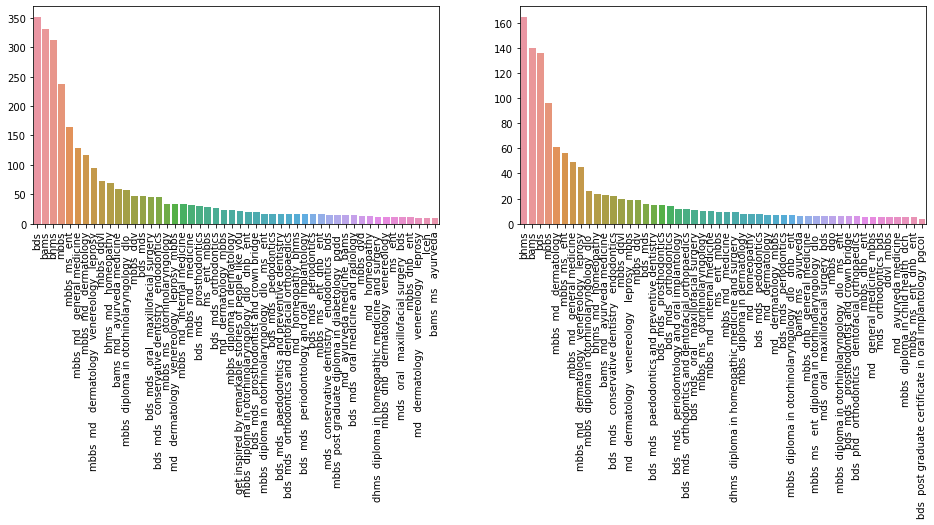

In [7]:
plt.figure(figsize=(16, 4))

plt.subplot(121)
plot_feature_freq(train, 'Qualification', showing=50)

plt.subplot(122)
plot_feature_freq(test, 'Qualification', showing=50)

# Ordena as qualificações pelas mais frequentes.
qualifications, counts = np.unique(train['Qualification'].dropna(), return_counts=True)
p = np.argsort(counts)[::-1]
qualifications = qualifications[p];

C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


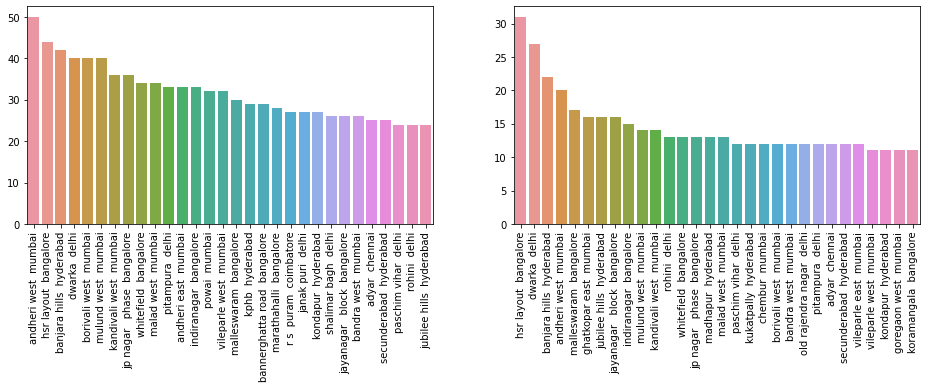

In [8]:
plt.figure(figsize=(16, 4))

plt.subplot(121)
plot_feature_freq(train, 'Place')

plt.subplot(122)
plot_feature_freq(test, 'Place')

# Ordena os locais pelos mais frequentes.
places, counts = np.unique(train['Place'].dropna(), return_counts=True)
p = np.argsort(counts)[::-1]
places = places[p];

C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


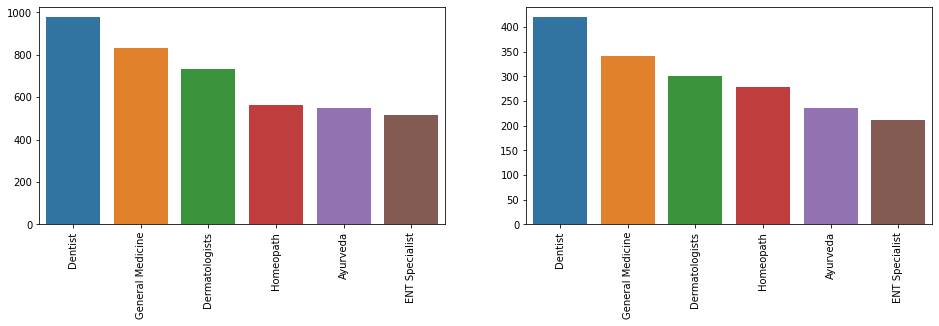

In [9]:
plt.figure(figsize=(16, 4))

plt.subplot(121)
plot_feature_freq(train, 'Profile')

plt.subplot(122)
plot_feature_freq(test, 'Profile');

### Modelando um regressor de custo de consulta

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

Vamos codificar as características categóricas usando o one-hot encoding.
Entretanto, dado o alto número de ocorrências únicas, nós consideramos somente os 100 valores de maior frequência.

In [11]:
retained_qualif = qualifications[:100].tolist()
retained_places = places[:100].tolist()

qualif_places_enc = OneHotEncoder(categories=[retained_qualif, retained_places],
                                  handle_unknown='ignore')
profile_enc = OneHotEncoder()

Substituímos as células desconhecidas pelo valor mediano e normalizamos as características contínuas com o `StandardScaler`, o que os transforma em um conjunto de média 0, desvio padrão 1:

In [12]:
continuous_enc = make_pipeline(SimpleImputer(strategy='median'),
                               StandardScaler())

Compomos o pipeline, definindo quais colunas alimentarão quais codificadores, e aplicamos o transformador aos dados de entrada e aos valores de saída:

In [13]:
encoder = ColumnTransformer([
  ('q_pla', qualif_places_enc, ['Qualification', 'Place']),
  ('prof', profile_enc, ['Profile']),
  ('ex_ra', continuous_enc, ['Experience', 'Rating'])
])

train_e = encoder.fit_transform(train)
# Apesar da normalização ser imprescindível, ela está acontecendo no conjunto de teste com os parâmetros 
# que encontramos no cnjunto de treino. Logo, não estamos usando informação do teste, mas apenas adequando a
# faixa de valores para a faixa com a qual o modelo foi treinado.
test_e = encoder.transform(test)

fee_enc = StandardScaler()
ye_train = fee_enc.fit_transform(train[['Fees']].astype(float)).ravel()
ye_test = fee_enc.transform(test[['Fees']].astype(float)).ravel()

**Atividade (3 pts):** treine três ou mais regressores baseados em *máquina de vetor de suporte* com configurações distintas (Kernel, C, epislon) e reporte o seus respectivos erros quadráticos médios (MSE) sobre as porções de validação separadas. Discuta como os diversos parâmetros da SVR (Kernel, C, epislon) afetaramm a qualidade do seus regressores. A busca pelos hiperparâmetros deve usar um método formal como GridSerach, RandomSearch, etc.

Utilize o conjunto transformado pelas células acima `(train_e, ye_train)` e `(test_e, ye_test)`.

In [14]:
np.random.seed(1082141)
sns.set()

In [15]:
#imports
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [16]:
penaltyArray = np.logspace(-3,  1, 5)
epsilonArray = np.logspace(-3, -1, 3)

In [17]:
# RBF

param_grid = dict{
    'C': penaltyArray,
    'epsilon': epsilonArray,
    'kernel': ['rbf']
}

grid = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid.fit(train_e, ye_train)
grid.cv_results_['mean_test_score']

print('Melhor Score: %.3f\nMelhores parametros: %s\n' % (grid.best_score_, grid.best_params_))

best_params = grid.best_params_

regressor = SVR(kernel='rbf', 
                C=best_params['C'], 
                epsilon=best_params['epsilon'],
               ).fit(train_e, ye_train)

# Predição
prediction  = regressor.predict(test_e)
svr_rbf_mse = mean_squared_error(ye_test, prediction)

print("Melhor Modelo:")
print("MSE = ", svr_rbf_mse)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Melhor Score: -0.842
Melhores parametros: {'C': 1.0, 'epsilon': 0.1, 'kernel': 'rbf'}

Melhor Modelo:
MSE =  0.8038962243450666


In [18]:
# Linear

param_grid={
    'C': penaltyArray,
    'epsilon': epsilonArray,
    'kernel': ['linear']
}

grid = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid.fit(train_e, ye_train)

print('Melhor Score: %.3f\nMelhores parametros: %s\n' % (grid.best_score_, grid.best_params_))

best_params = grid.best_params_

regressor = SVR(kernel='linear', 
                C=best_params['C'], 
                epsilon=best_params['epsilon'],
               ).fit(train_e, ye_train)

# Predição
prediction  = regressor.predict(test_e)
svr_lin_mse = mean_squared_error(ye_test, prediction)

print("Melhor Modelo:")
print("MSE = ", svr_lin_mse)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Melhor Score: -0.861
Melhores parametros: {'C': 0.1, 'epsilon': 0.1, 'kernel': 'linear'}

Melhor Modelo:
MSE =  0.8280827914268084


In [19]:
# Polinomial

param_grid={
    'C': penaltyArray,
    'epsilon': epsilonArray,
    'degree': [1, 2, 3, 4, 5],
    'kernel': ['poly']
}

grid = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid.fit(train_e, ye_train)
grid.cv_results_['mean_test_score']

print('Melhor Score: %.3f\nMelhores parametros: %s\n' % (grid.best_score_, grid.best_params_))

best_params = grid.best_params_

regressor = SVR(kernel='poly', 
                C=best_params['C'], 
                epsilon=best_params['epsilon'], 
                degree=best_params['degree']
               ).fit(train_e, ye_train)

# Predição
prediction  = regressor.predict(test_e)
svr_pol_mse = mean_squared_error(ye_test, prediction)

print("Melhor Modelo:")
print("MSE = ", svr_pol_mse)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Melhor Score: -0.870
Melhores parametros: {'C': 1.0, 'degree': 2, 'epsilon': 0.1, 'kernel': 'poly'}

Melhor Modelo:
MSE =  0.8064073963952342


Para o parâmetro **Kernel**, vimos que o kernel RBF foi a função de decisão que mostrou maior capacidade de generalização e por isso melhor performance. Em contrapartida, o kernel linear, por ser menos flexível aos dados, foi a função de decisão que obteve o pior resultado. 

O valor **C** como representa a penalidade, observamos que um valor maior (1.0) para um kernel mais flexível performou melhor. Porém, com um kernel menos flexível como o linear, foi necessário um valor de C menor para se obter melhores resultados (0.1)

Os melhores valores de **epsilon** não variou. Foi o mesmo nas três abordagens (0.1). Contudo, é importante observar que se epsilon fosse muito baixo, muitos erros eram penalizados e isto dificultava a generalização, podendo levar ao overfitting.

**Atividade (2 pts):** Treine 2 outros regressores a sua escolha (Regressão linear, polinomial, árvore de regeressão, etc.) e compare o resultado dos modelos com a sua melhor SVR no conjunto de teste, discuntindo os resultados.

Utilize o conjunto transformado pelas células acima `(train_e, ye_train)` e `(test_e, ye_test)`.

**Regressão Linear**

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_e, ye_train)

prediction = lr.predict(test_e)

print("MSE = ", mean_squared_error(ye_test, prediction))

MSE =  0.8273587653494651


**Decision Tree Regression**

In [22]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor(max_depth=5, random_state=10)
dtr.fit(train_e, ye_train)

prediction = dtr.predict(test_e)
dtr_mse    = mean_squared_error(ye_test, prediction)

print("MSE = ", dtr_mse)

MSE =  0.8697421328951505


**Random Forest Regressor**

In [23]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(max_depth=10, random_state=10)
rfr.fit(train_e, ye_train)

prediction = rfr.predict(test_e)
rfr_mse    = mean_squared_error(ye_test, prediction)

print("MSE = ", rfr_mse)

MSE =  0.7912958116172196


**Comparando Resutados**

In [24]:
print("MSE",
      "SVR com Kernel RBF:       %.4f" % (svr_rbf_mse),
      "Random Forest Regression: %.4f" % (rfr_mse),
      sep='\n')

MSE
SVR com Kernel RBF:       0.8039
Random Forest Regression: 0.7913


Os dois modelos obtiveram erros quadráticos médios (MSE) muito parecidos, porém a Random Forest com árvores de regressão obteve uma pequena vantagem. Pois esta utiliza-se do método de ensemble para aplicar agrupamento visando melhores predições do que uma árvore de regressão isolada. Sendo assim menos complexa e mais acertiva.

## PARTE II - Classificando imagens de dígitos
### Lendo o conjunto de dados

**Pen-Based Recognition of Handwritten Digits Data Set**
é um banco de imagens simples e bem conhecido em reconhecimento de imagens.  
Ele é composto por imagens em escala cinza de 8 por 8 pixels divididas em 10 classes de dígitos.

Uma descrição completa pode ser encontrada no seguinte link: [archive.ics.uci.edu/ml/datasets/Pen-Based+Recognition+of+Handwritten+Digits](http://archive.ics.uci.edu/ml/datasets/Pen-Based+Recognition+of+Handwritten+Digits)

In [25]:
x, y = datasets.load_digits(return_X_y=True)

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=.5,
                                                    random_state=183212)
print('amostras em treino: %i' % x_train.shape[0],
      'amostras em teste: %i' % x_test.shape[0],
      'número de características: %i' % x_train.shape[1],
      'número de classes: %i' % (np.max(y_train) + 1),
      sep='\n', end='\n\n')

amostras em treino: 898
amostras em teste: 899
número de características: 64
número de classes: 10



### 256 primeiras amostras no conjunto de treinamento

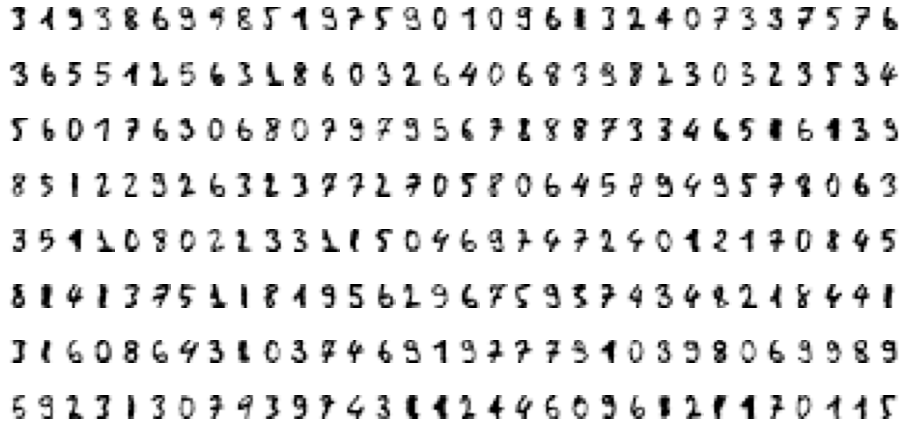

In [26]:
plt.figure(figsize=(16, 8))

for ix in range(8  * 32):
    plt.subplot(8, 32, ix + 1)
    plt.imshow(x_train[ix].reshape(8, 8), cmap='Greys')
    plt.axis('off')

### Visualizando o conjunto e frequências das classes

C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


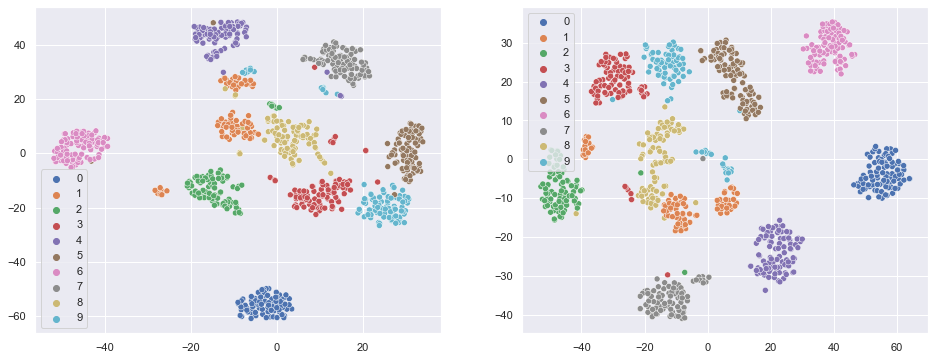

In [27]:
from sklearn.manifold import TSNE

encoder2D = TSNE()
w_train = encoder2D.fit_transform(x_train)
w_test = encoder2D.fit_transform(x_test)

plt.figure(figsize=(16, 6))
categorical_colors = sns.color_palette()

for ix, (x, y) in enumerate(((w_train, y_train), (w_test, y_test))):
    plt.subplot(1, 2, ix + 1)
    sns.scatterplot(*x.T, hue=y, palette=categorical_colors);

C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\danil\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


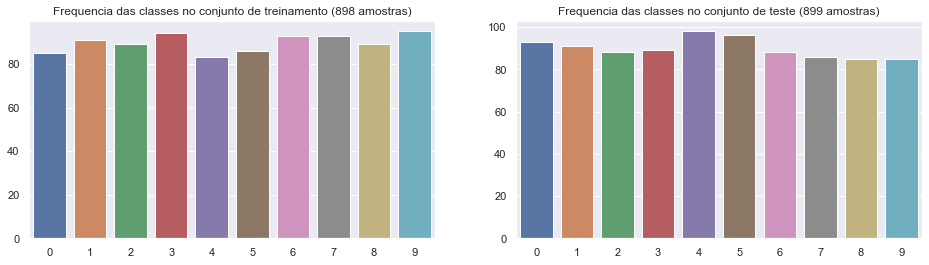

In [28]:
plt.figure(figsize=(16, 4))

plt.subplot(121)
plt.title('Frequencia das classes no conjunto de treinamento (%i amostras)' % len(x_train))
labels, counts = np.unique(y_train, return_counts=True)
sns.barplot(labels, counts)

plt.subplot(122)
plt.title('Frequencia das classes no conjunto de teste (%i amostras)' % len(x_test))
labels, counts = np.unique(y_test, return_counts=True)
sns.barplot(labels, counts);

### Modelando um classificador de digitos com SVM Linear

**Atividade (1 pt):** defina e treine uma máquina de vetor de suporte com kernel linear, utilizando o scikit-learn. Encontre o melhor valor do parâmetro C, definindo um intervalo de busca e fazendo um grid search com validação cruzada em 10 folds.

In [29]:
c_range     = np.logspace(-4, 3, 8)
gamma_range = np.logspace(-4, 3, 8)

In [30]:
from sklearn.svm import SVC

#Linear
param_grid = {'C':c_range, 
              'kernel':['linear']}

grid_lin = GridSearchCV(SVC(), param_grid,verbose=1, scoring='accuracy', cv=10)
grid_lin.fit(x_train, y_train)
print('Melhor Score: %.3f\nMelhores parametros para Linear: %s\n' % (grid_lin.best_score_, grid_lin.best_params_))

Fitting 10 folds for each of 8 candidates, totalling 80 fits
Melhor Score: 0.977
Melhores parametros para Linear: {'C': 0.01, 'kernel': 'linear'}



### Avaliando o modelo treinado

**Atividade (1 pt):** avalie o modelo treinado com o melhor valor encontrado para o parâmetro C sobre o conjunto de teste previamente separado. Reporte a acurácia média e a matriz de confusão.

In [31]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

best_clf = SVC(kernel='linear', C=grid_lin.best_params_['C'])
best_clf.fit(x_train, y_train) 
testPred = best_clf.predict(x_test)

# Acurácia Média
testAcc  = accuracy_score(y_test, testPred)
print("Acuracia Teste: %.3f" % (testAcc))

# Matriz de Confusão
print(confusion_matrix(y_test, testPred))

Acuracia Teste: 0.972
[[92  0  0  0  1  0  0  0  0  0]
 [ 0 91  0  0  0  0  0  0  0  0]
 [ 0  0 88  0  0  0  0  0  0  0]
 [ 0  0  0 88  0  0  0  0  1  0]
 [ 0  2  0  0 96  0  0  0  0  0]
 [ 0  1  0  0  0 95  0  0  0  0]
 [ 2  0  0  0  0  0 86  0  0  0]
 [ 0  0  0  0  2  5  0 78  0  1]
 [ 0  3  1  2  0  1  0  0 78  0]
 [ 0  0  0  1  0  1  0  0  1 82]]


### Modelando um classificador de digitos com SVM com kernel RBF

**Atividade (1 pt):** utilizando o kernel RBF, defina e treine uma máquina de vetor de suporte. Faça um grid search nos valores de C e gamma com validação cruzada em 10 folds.

In [32]:
param_grid = {'C':c_range, 
              'gamma':gamma_range, 
              'kernel':['rbf']}

grid_rbf = GridSearchCV(SVC(), param_grid, verbose=1, scoring='accuracy', cv=10)
grid_rbf.fit(x_train, y_train)

grid_score = grid_rbf.best_score_
print('Melhor Score: %.3f\nMelhores parametros: %s\n' % (grid_score, grid_rbf.best_params_))

Fitting 10 folds for each of 64 candidates, totalling 640 fits
Melhor Score: 0.990
Melhores parametros: {'C': 1.0, 'gamma': 0.001, 'kernel': 'rbf'}



**Atividade (1 pt):** aumente o intervalo de busca de C e gamma e faça uma busca randômica pelo intervalo. 

In [33]:
from sklearn.model_selection import RandomizedSearchCV

c_range     = np.logspace(-6, 6, 8)
gamma_range = np.logspace(-6, 6, 8)

params = {
    'C': c_range,
    'gamma':gamma_range, 
    'kernel':['rbf']
}

rand = RandomizedSearchCV(SVC(), params, cv=10, scoring='accuracy', random_state=5)
rand.fit(x_train, y_train)

rand_score = rand.best_score_
print('Melhor Score: %.3f\nMelhores parametros: %s\n' % (rand_score, rand.best_params_))

Melhor Score: 0.977
Melhores parametros: {'kernel': 'rbf', 'gamma': 1e-06, 'C': 1000000.0}



### Avaliando os melhores modelos

**Atividade (1 pt):** utilizando o melhor par de valores encontrado para C e gamma, em cada uma das estratégias, treine e avalie um modelo sobre o conjunto de teste previamente separado. Reporte a acurácia média e a matriz de confusão para com cada modelo.

**Grid Search**

In [34]:
best_clf = SVC(kernel='rbf', 
               C=grid_rbf.best_params_['C'], 
               gamma=grid_rbf.best_params_['gamma']
              )

best_clf.fit(x_train, y_train) 
testPred = best_clf.predict(x_test)

# Acurácia Média
testAcc  = accuracy_score(y_test, testPred)
print("Acuracia Teste: %.3f\n" % (testAcc))

# Matriz de Confusão
print(confusion_matrix(y_test, testPred))

Acuracia Teste: 0.987

[[92  0  0  0  1  0  0  0  0  0]
 [ 0 91  0  0  0  0  0  0  0  0]
 [ 0  0 88  0  0  0  0  0  0  0]
 [ 0  0  1 88  0  0  0  0  0  0]
 [ 0  1  0  0 97  0  0  0  0  0]
 [ 0  0  0  0  0 96  0  0  0  0]
 [ 0  0  0  0  0  1 86  0  1  0]
 [ 0  0  0  0  0  0  0 84  0  2]
 [ 0  2  0  0  0  0  0  0 83  0]
 [ 0  0  0  1  0  1  0  0  1 82]]


**Random Search**

In [35]:
best_clf = SVC(kernel='rbf', 
               C=rand.best_params_['C'], 
               gamma=rand.best_params_['gamma']
              )

best_clf.fit(x_train, y_train) 
testPred = best_clf.predict(x_test)

# Acurácia Média
testAcc  = accuracy_score(y_test, testPred)
print("Acuracia Teste: %.3f\n" % (testAcc))

# Matriz de Confusão
print(confusion_matrix(y_test, testPred))

Acuracia Teste: 0.972

[[92  0  0  0  1  0  0  0  0  0]
 [ 0 91  0  0  0  0  0  0  0  0]
 [ 0  0 88  0  0  0  0  0  0  0]
 [ 0  0  0 88  0  0  0  0  1  0]
 [ 0  2  0  0 96  0  0  0  0  0]
 [ 0  1  0  0  0 95  0  0  0  0]
 [ 2  0  0  0  0  0 86  0  0  0]
 [ 0  0  0  0  2  5  0 78  0  1]
 [ 0  3  1  2  0  1  0  0 78  0]
 [ 0  0  0  1  0  1  0  0  1 82]]
